In [1]:
from myutils import parallelize, cache
import matplotlib as mpl
mpl.rcdefaults()
from src import *

# Use TeX

In [2]:
width = 8.5 / 2.54 #inches

plt.rcParams['text.usetex'] = True
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb, physics, newtxtext, newtxmath, courier, fix-cm, helvet}'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb, physics}'

formatter = ScalarFormatter(useMathText=True)
formatter.set_useOffset(False)  
formatter.set_powerlimits((0, 0))


# Color and marker

In [3]:
spade_params = {
    'marker': 'o',
    'edgecolors': 'tab:blue',
    'facecolors': 'none',
    's': 7,
    'linewidths': 0.5
}

di_params = {
    'marker': '+',
    'facecolor': 'k',
    's': 9,
    'linewidths': 0.5
}

hg_params = {
    'marker': 'D',
    'edgecolors': 'tab:green',
    'facecolors': 'none',
    's': 5,
    'linewidths': 0.5
}

c_red = 'tab:orange'

In [4]:
# STOP HERE
raise

RuntimeError: No active exception to reraise

---
# Main Text

## Ideal

## Noisy

---
# Supplemental Material

## $\gamma$

In [ ]:
params = {
    'zorder': 3,
    'clip_on': False,
    'linewidth': 1.35,
}

fig = plt.figure(figsize=(width, width))

s = 0.5 * DI.SIGMA

def i(b, sigma=DI.SIGMA):
    from scipy.integrate import quad
    b_ = b * sigma
    func = lambda x: (x**2 * np.exp(-x**2)) / (np.sqrt(2*np.pi)*np.exp(-x**2/2) + 2*np.pi*b_)
    return quad(func, -np.inf, np.inf)[0] / sigma**2

x = np.linspace(1e-10, 1, 300)
y_DI_continue = np.array([i(x_) for x_ in x]) * DI.SIGMA**2
y_DI = np.array([DI.gamma(b, s) for b in x]) * DI.SIGMA**2
y_PM = np.array([PM_SPADE.gamma(b, s) for b in x]) * DI.SIGMA**2
y_HG = np.array([HG_SPADE.gamma(b, s) for b in x]) * DI.SIGMA**2


plt.plot(x, y_DI_continue, label=r'Direct imaging (infinitesimal $a$)', linestyle='-', color='tab:purple', **params)
plt.plot(x, y_DI, label=r'Direct imaging ($a=4.6\,$\textmu m)', linestyle='-.', color='k', **params)
plt.plot(x, y_PM, label=r'PM-SPADE', linestyle='--', color='tab:blue', **params)
plt.plot(x, y_HG, label=r'HG-SPADE', linestyle=(0, (1, 1)), color='tab:green', **params)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel(r"$b/\nu$")
plt.ylabel(r'$\sigma^2\gamma$')

plt.gca().set_box_aspect(0.618)
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2)) 
plt.legend(frameon=False, loc='upper right')
plt.title(r'$s=0.5\sigma$')
plt.tight_layout()
plt.savefig('gamma.pdf', bbox_inches='tight')

plt.show()

## CFI

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(width * 1.6, width * 1.1), sharex='col', constrained_layout=True)

params = {
    'di': dict(label='Direct imaging', linestyle='-.', color='k', zorder=3, linewidth=1.35),
    'pm': dict(label='PM-SPADE', linestyle='--', color='tab:blue', zorder=3, linewidth=1.35),
    'hg': dict(label='HG-SPADE', linestyle=(0, (1, 1)), color='tab:green', zorder=3, linewidth=1.35),
}


# (0, 0)
b_range = np.linspace(0, 0.1, 300)
A = DMD.A(5)
QCRB = DI.CFI(0, A, 0.2)
ax = axes[0, 0]

ax.plot(b_range, [DI.CFI(b, A, 0.2) / QCRB for b in b_range], **params['di'], clip_on=False)
ax.plot(b_range, [PM_SPADE.CFI(b, A, 0.2) / QCRB for b in b_range], **params['pm'], clip_on=False)
ax.plot(b_range, [HG_SPADE.CFI(b, A, 0.2) / QCRB for b in b_range], **params['hg'], clip_on=False)



# (0, 1)
b_range = np.linspace(100, 1000, 300)
ax = axes[0, 1]

ax.plot(b_range, [DI.CFI(b, A, 0.2) / QCRB for b in b_range], **params['di'], clip_on=False)
ax.plot(b_range, [PM_SPADE.CFI(b, A, 0.2) / QCRB for b in b_range], **params['pm'], clip_on=False)
ax.plot(b_range, [HG_SPADE.CFI(b, A, 0.2) / QCRB for b in b_range], **params['hg'], clip_on=False)



# (1, 0)
b_range = np.linspace(0, 0.1, 300)
A = 0.01 * DI.SIGMA
QCRB = DI.CFI(0, A, 0.2)
ax = axes[1, 0]

ax.plot(b_range, [DI.CFI(b, A, 0.2) / QCRB for b in b_range], **params['di'], clip_on=False)
ax.plot(b_range, [PM_SPADE.CFI(b, A, 0.2) / QCRB for b in b_range], **params['pm'], clip_on=False)
ax.plot(b_range, [HG_SPADE.CFI(b, A, 0.2) / QCRB for b in b_range], **params['hg'], clip_on=False)
ax.set_xlabel(r'$b / \nu$')



# (1, 1) + inset
b_range = np.linspace(100, 1000, 300)
QCRB = DI.CFI(0, A, 0.2)
ax = axes[1, 1]

di_, = ax.plot(b_range, [DI.CFI(b, A, 0.2) / QCRB for b in b_range], **params['di'], clip_on=False)
pm_, = ax.plot(b_range, [PM_SPADE.CFI(b, A, 0.2) / QCRB for b in b_range], **params['pm'], clip_on=False)
hg_, = ax.plot(b_range, [HG_SPADE.CFI(b, A, 0.2) / QCRB for b in b_range], **params['hg'], clip_on=False)
ax.set_xlabel(r'$b / \nu$')
ax.set_xticks(np.linspace(100, 1000, 4), np.linspace(100, 1000, 4).astype(int))


# inset
ax_inset = inset_axes(ax, width='40%', height='40%', loc='upper right', borderpad=1.5)
ax_inset.plot(b_range, [DI.CFI(b, A, 0.2) / QCRB for b in b_range], **params['di'])
ax_inset.plot(b_range, [PM_SPADE.CFI(b, A, 0.2) / QCRB for b in b_range], **params['pm'])
ax_inset.plot(b_range, [HG_SPADE.CFI(b, A, 0.2) / QCRB for b in b_range], **params['hg'], clip_on=False)
ax_inset.set_xlim(100, 1000)
ax_inset.set_ylim(0, 1.42e-5)

ax_inset.yaxis.set_major_formatter(formatter)
ax_inset.set_xticks(np.linspace(100, 1000, 4), np.linspace(100, 1000, 4).astype(int))
ax_inset.xaxis.set_minor_locator(AutoMinorLocator(2))
ax_inset.yaxis.set_minor_locator(AutoMinorLocator(2))


for ax in axes.ravel():
    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.set_ylabel(r'Normalized CFI')
    ax.yaxis.set_major_formatter(formatter)

for i in (0, 1):
    axes[0, i].set_title(r'$A=0.47\sigma;\quad f=0.2$')
    axes[1, i].set_title(r'$A=0.01\sigma;\quad f=0.2$')

    axes[i, 0].set_xlim(0, 0.1)
    axes[i, 0].set_ylim(0, 1)

    axes[i, 1].set_xlim(100, 1000)
    axes[i, 1].set_ylim(0, None)


fig.legend([di_, pm_, hg_], ['Direct imaging', 'PM-SPADE', 'HG-SPADE'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.06), frameon=False)

plt.savefig('cfi.pdf')
plt.show()


## Intuitive

In [ ]:
def plot_data():
    def binning(c):
        binned_1 = qCMOS.convert2photons(c.cropped_data[0, 0], 0).reshape(-1, 8).sum(-1)
        binned_2 = qCMOS.convert2photons(c.cropped_data[0, 4], 0).reshape(-1, 8).sum(-1)

        return binned_1, binned_2

    binned_1, binned_2 = binning(LoadEstimates('data/noisy/di_5px_f0.2_d0.npz'))
    binned_3, binned_4 = binning(LoadEstimates('data/noisy/di_5px_f0.2_d92.npz'))


    width = 0.18
    spade_c1 = LoadEstimates('data/noisy/spade_5px_f0.2_d0.npz')
    spade_c2 = LoadEstimates('data/noisy/spade_5px_f0.2_d92.npz')

    y1 = qCMOS.convert2photons(spade_c1.cropped_data[0, 0], 0)
    y2 = qCMOS.convert2photons(spade_c1.cropped_data[0, 4], 0)

    y3 = qCMOS.convert2photons(spade_c2.cropped_data[0, 0], 0)
    y4 = qCMOS.convert2photons(spade_c2.cropped_data[0, 4], 0)

    _plot_data = [
        [np.arange(25)+0.5, binned_1], [np.arange(25)+0.5, binned_2],  # ax[0, 0]
        [np.arange(25)+0.5, binned_3], [np.arange(25)+0.5, binned_4],  # ax[1, 0]

        [[0, (1 - 0.2)], [y1[0], y1[1]]], [[(0.02+width), (1.02+width - 0.2)], [y2[0], y2[1]]],  # ax[0, 1]
        [[0, (1 - 0.2)], [y3[0], y3[1]]], [[(0.02+width), (1.02+width - 0.2)], [y4[0], y4[1]]]   # ax[1, 1]
    ]

    return _plot_data


di_ideal = np.load(r'raw\noisy\di_5px\di_5px_f0.2_d0_raw.npy')
di_noisy = np.load(r'raw\noisy\di_5px\di_5px_f0.2_d42_raw.npy')


pm_ideal = np.load(r'raw\noisy\spade_5px\spade_5px_f0.2_d0_raw.npy')
pm_noisy = np.load(r'raw\noisy\spade_5px\spade_5px_f0.2_d92_raw.npy')

# di_ideal = np.load(r'raw\ideal\di_5px\di_5px_f0.1_d0_raw.npy')
# di_noisy = np.load(r'raw\ideal\di_5px\di_5px_f0.4_d0_raw.npy')


# pm_ideal = np.load(r'raw\ideal\spade_5px\spade_5px_f0.1_d0_raw.npy')
# pm_noisy = np.load(r'raw\ideal\spade_5px\spade_5px_f0.4_d0_raw.npy')


raw = {
    'di_ideal': {'0': qCMOS.convert2photons(di_ideal[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(di_ideal[0, 4, :-4, :].astype(float), 0)},

    'di_noisy': {'0': qCMOS.convert2photons(di_noisy[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(di_noisy[0, 4, :-4, :].astype(float), 0)},

    'pm_ideal': {'0': qCMOS.convert2photons(pm_ideal[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(pm_ideal[0, 4, :-4, :].astype(float), 0)},

    'pm_noisy': {'0': qCMOS.convert2photons(pm_noisy[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(pm_noisy[0, 4, :-4, :].astype(float), 0)},
}


limit = {
    'di_ideal': {'vmin': min(raw['di_ideal']['0'].min(), raw['di_ideal']['2a'].min()),
                 'vmax': max(raw['di_ideal']['0'].max(), raw['di_ideal']['2a'].max())},

    'di_noisy': {'vmin': min(raw['di_noisy']['0'].min(), raw['di_noisy']['2a'].min()),
                 'vmax': max(raw['di_noisy']['0'].max(), raw['di_noisy']['2a'].max())},

    'pm_ideal': {'vmin': min(raw['pm_ideal']['0'].min(), raw['pm_ideal']['2a'].min()),
                 'vmax': max(raw['pm_ideal']['0'].max(), raw['pm_ideal']['2a'].max())},

    'pm_noisy': {'vmin': min(raw['pm_noisy']['0'].min(), raw['pm_noisy']['2a'].min()),
                 'vmax': max(raw['pm_noisy']['0'].max(), raw['pm_noisy']['2a'].max())},
}

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(width * 1.6, width * 1.1), sharex='col', constrained_layout=True)

data = plot_data()

params = dict(alpha=0.6, edgecolor='black', linewidth=0.3)

axes[0, 0].bar(*data[0], label=r'$s=0$', **params)
axes[0, 0].bar(*data[1], label=r'$s=2A$', **params)

axes[1, 0].bar(*data[2], label=r'$s=0$', **params)
axes[1, 0].bar(*data[3], label=r'$s=2A$', **params)

axes[0, 1].bar(*data[4], width=0.18, label=r'$s=0$', **params)
axes[0, 1].bar(*data[5], width=0.18, label=r'$s=2A$', **params)

axes[1, 1].bar(*data[6], width=0.18, label=r'$s=0$', **params)
axes[1, 1].bar(*data[7], width=0.18, label=r'$s=2A$', **params)

axes[0, 0].set_title('Direct imaging')
axes[0, 1].set_title('PM-SPADE')

axes[0, 0].set_ylabel('Photons (binned)')
axes[1, 0].set_ylabel('Photons (binned)')

axes[0, 1].tick_params(axis='x', which='minor', bottom=False, top=False)
axes[1, 1].tick_params(axis='x', which='minor', bottom=False, top=False)

axes[0, 0].set_xticks(np.linspace(0, 25, 6), np.linspace(0, 200, 6).astype(int))
axes[1, 0].set_xticks(np.linspace(0, 25, 6), np.linspace(0, 200, 6).astype(int))

axes[0, 0].set_xlim(0, 25)
axes[1, 0].set_xlim(0, 25)

axes[0, 1].set_xlim(-0.5, 1.5)
axes[1, 1].set_xlim(-0.5, 1.5)

axes[0, 0].set_ylim(0, 80*1.02)
axes[1, 0].set_ylim(0, 1500*1.02)
axes[0, 1].set_ylim(0, 110*1.02)
axes[1, 1].set_ylim(0, 145*1.02)

axes[1, 0].set_xlabel('Pixel (binned)')
axes[1, 1].set_xlabel('Mode')
axes[0, 1].set_ylabel('Photons')
axes[1, 1].set_ylabel('Photons')
axes[0, 1].set_xticks([0.1, 1.1 - 0.2], [r'$\phi_+$', r'$\phi_-$'])
axes[1, 1].set_xticks([0.1, 1.1 - 0.2], [r'$\phi_+$', r'$\phi_-$'])

for i, ax in enumerate(axes.ravel()):
    ax.set_box_aspect(0.618)
    ax.legend(frameon=False, loc='upper left')
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))



for i, fig_name in enumerate(['di_ideal', 'di_noisy']):
    inset1 = inset_axes(axes[i, 0], width=0.4, height=0.4, loc='upper right', bbox_to_anchor=(0.85, 1), bbox_transform=axes[i, 0].transAxes)
    inset1.imshow(raw[fig_name]['0'], **limit[fig_name])
    inset1.scatter([DI.X_AXIS]*20, np.linspace(0, 223, 20), s=1, color='tab:blue', edgecolor='black', linewidths=0.3)
    inset1.set_xticks([])
    inset1.set_yticks([])

    inset2 = inset_axes(axes[i, 0], width=0.4, height=0.4, loc='upper right', bbox_to_anchor=(1.02, 1), bbox_transform=axes[i, 0].transAxes)
    inset2.imshow(raw[fig_name]['2a'], **limit[fig_name])
    inset2.scatter([DI.X_AXIS]*20, np.linspace(0, 223, 20), s=1, color='tab:orange', edgecolor='black', linewidths=0.3)
    inset2.set_xticks([])
    inset2.set_yticks([])


for i, fig_name in enumerate(['pm_ideal', 'pm_noisy']):
    inset1 = inset_axes(axes[i, 1], width=0.6, height=0.6, loc='upper right', bbox_to_anchor=(0.95, 1), bbox_transform=axes[i, 1].transAxes)
    inset1.imshow(raw[fig_name]['0'], **limit[fig_name])
    inset1.scatter([SPADE.X_AXIS]*2, [SPADE.POINT_1, SPADE.POINT_2], color='tab:blue', marker='X', edgecolors='black', linewidths=0.3, s=5)
    inset1.set_xticks([])
    inset1.set_yticks([])

    inset2 = inset_axes(axes[i, 1], width=0.6, height=0.6, loc='upper right', bbox_to_anchor=(1.085, 1), bbox_transform=axes[i, 1].transAxes)
    inset2.imshow(raw[fig_name]['2a'], **limit[fig_name])
    inset2.scatter([SPADE.X_AXIS]*2, [SPADE.POINT_1, SPADE.POINT_2], color='tab:orange', marker='X', edgecolors='black', linewidths=0.3, s=5)
    inset2.set_xticks([])
    inset2.set_yticks([])

plt.savefig('intuitive.pdf')
plt.show()

# Simulation

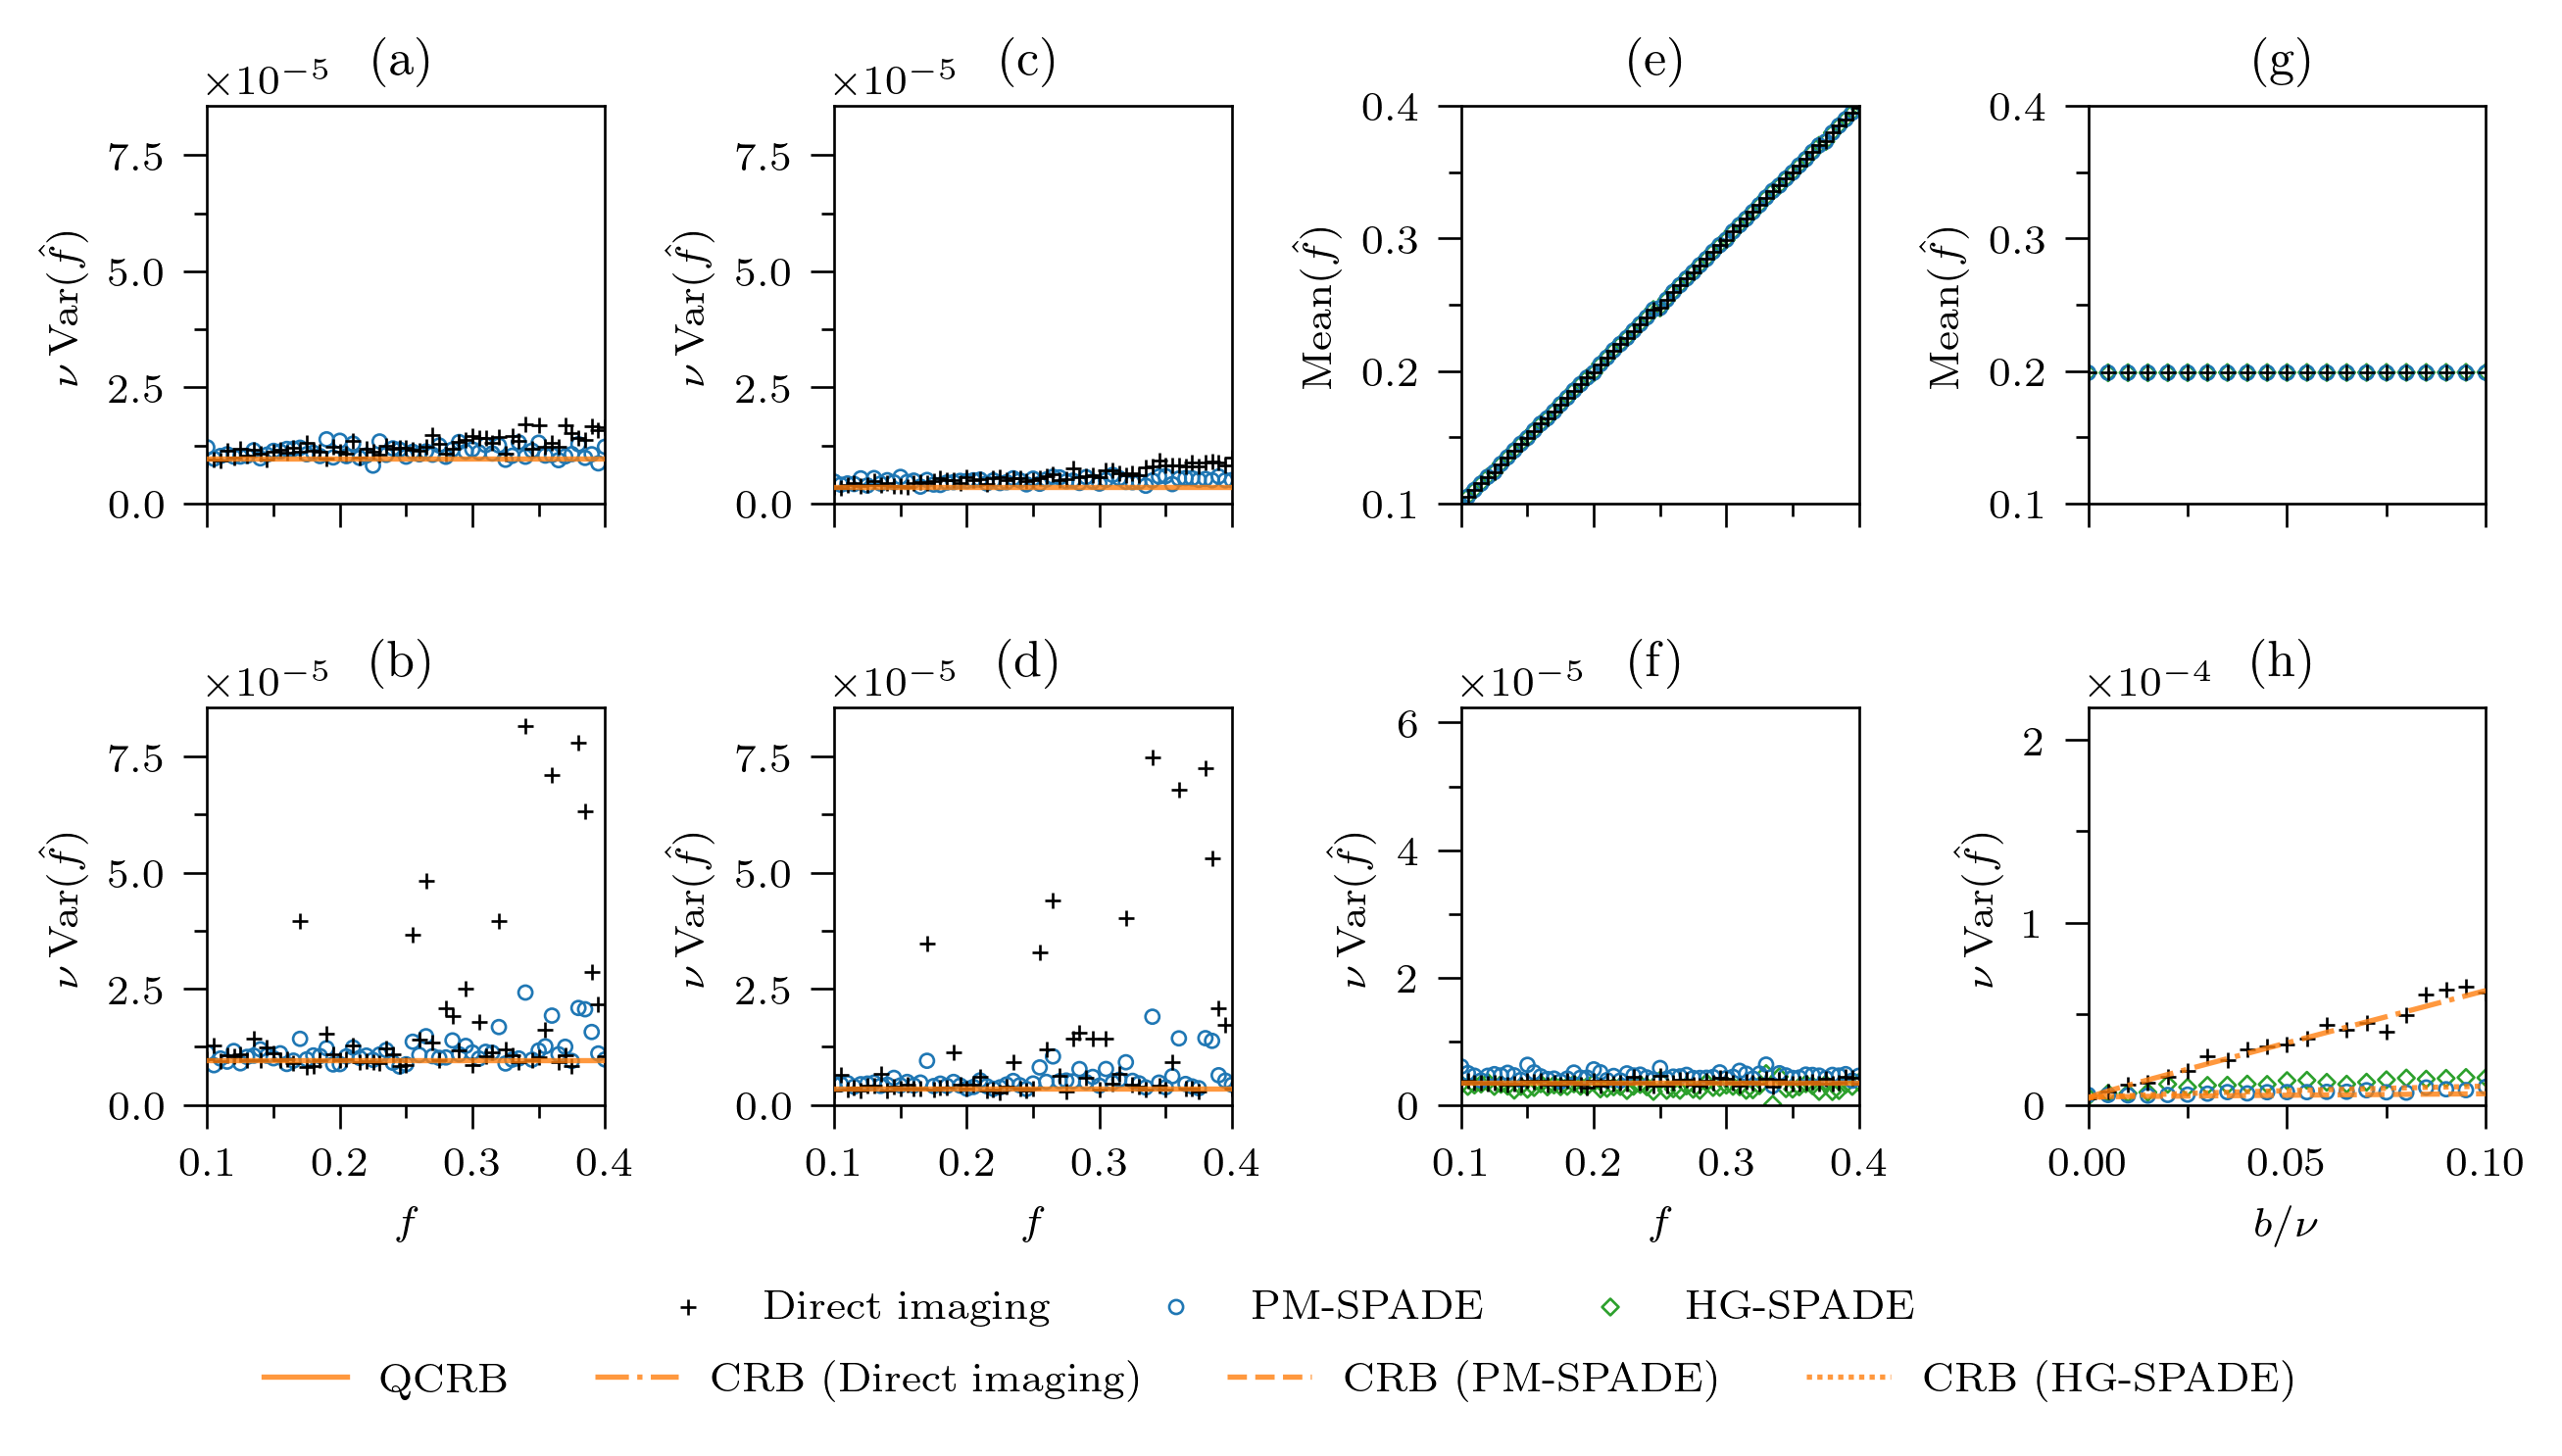

In [48]:
fig, axes = plt.subplots(2, 4, figsize=(width * 2, width * 1), sharex='col', constrained_layout=True)
freq_list = np.linspace(0.1, 0.4, 61)
b_list = np.linspace(0, 0.1, 21)

for j, a in enumerate((3, 5)):
    fi = DI.ApproxCFI((4 / pi) * DMD.A(a))
    axes[0, j].axhline(1/fi, color=c_red, zorder=3, alpha=0.8)
    axes[1, j].axhline(1/fi, color=c_red, zorder=3, alpha=0.8)

qcrb = axes[1, 2].axhline(1/fi, color=c_red, zorder=3, alpha=0.8)

hg_crb, = axes[1, 3].plot(np.linspace(0, 0.1, 100), 
                          1/HG_SPADE.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), linestyle=(0, (1, 1)), color=c_red, zorder=3, alpha=0.8)

pm_crb, = axes[1, 3].plot(np.linspace(0, 0.1, 100), 
                          1/PM_SPADE.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), '--', color=c_red, zorder=3, alpha=0.8)

di_crb, = axes[1, 3].plot(np.linspace(0, 0.1, 100), 
                          1/DI.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), '-.', color=c_red, zorder=3, alpha=0.8)

f_var_max = 0
for k, w in enumerate(('SIN', 'SIGN')):
    for j, a in enumerate((3, 5)):
        for m in ('SPADE', 'DI'):

            f_var = np.load(rf'result/sim/{w.lower()}/{m.lower()}_{a}px.npz')['var']

            if m.lower() == 'spade':
                axes[k, j].scatter(freq_list, f_var, **spade_params, label=m)
            elif m.lower() == 'di':
                axes[k, j].scatter(freq_list, f_var, **di_params, label=m)

            f_var_max = max(f_var_max, np.max(f_var))


# axes[0, 0].set_title(r'$0.28 \sigma \cdot \sin(2\pi f n)$', loc="right")
# axes[0, 1].set_title(r'$0.47 \sigma \cdot \sin(2\pi f n)$', loc="right")
# axes[1, 0].set_title(r'$0.28 \sigma \cdot \operatorname{sgn}\qty[\sin(2\pi f n)]$', loc="right")
# axes[1, 1].set_title(r'$0.47 \sigma \cdot \operatorname{sgn}\qty[\sin(2\pi f n)]$', loc="right")

for i, ax in enumerate(axes.T.ravel()):
    t = 'abcdefghijklmn'
    ax: plt.Axes
    ax.set_title(rf'({t[i]})')
    ax.set_box_aspect(1)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_major_formatter(formatter)

for i, ax in enumerate(axes.T.ravel()[:4]):
    ax.set_ylabel(r'$\nu\operatorname{Var}(\hat f)$')
    ax.set_ylim(0, f_var_max * 1.05)
    ax.set_xticks(np.linspace(0.1, 0.4, 4))
    temp_formatter = ScalarFormatter(useMathText=True)
    temp_formatter.set_powerlimits((-5, -5))
    ax.yaxis.set_major_formatter(temp_formatter)

for i in range(2, 4):
    axes[0, i].set_ylabel(r'$\operatorname{Mean}(\hat f)$')
    axes[0, i].set_ylim(0.1, 0.4)
    axes[0, i].set_yticks(np.linspace(0.1, 0.4, 4))
    axes[1, i].set_ylabel(r'$\nu\operatorname{Var}(\hat f)$')

for i in range(3):
    axes[1, i].set_xlim(0.1, 0.4)
    axes[1, i].set_xlabel(r'$f$')
    axes[1, i].set_xticks(np.linspace(0.1, 0.4, 4))

axes[1, 3].set_xlabel(r'$b/\nu$')
axes[1, 3].set_xlim(0, 0.1)
axes[1, 3].set_ylim(0, 2.18e-4)
axes[1, 2].set_ylim(0, 1.04*6e-5)



f_mean_list, f_var_list = np.load(f'result/sim/ideal/hg_5px.npz')['mean'], np.load(f'result/sim/ideal/hg_5px.npz')['var']
hg = axes[0, 2].scatter(freq_list, f_mean_list, **hg_params)
hg = axes[1, 2].scatter(freq_list, f_var_list, **hg_params)

f_mean_list, f_var_list = np.load(f'result/sim/ideal/spade_5px.npz')['mean'], np.load(f'result/sim/ideal/spade_5px.npz')['var']
pm = axes[0, 2].scatter(freq_list, f_mean_list, **spade_params)
pm = axes[1, 2].scatter(freq_list, f_var_list, **spade_params)

f_mean_list, f_var_list = np.load(f'result/sim/ideal/di_5px.npz')['mean'], np.load(f'result/sim/ideal/di_5px.npz')['var']
di = axes[0, 2].scatter(freq_list, f_mean_list, **di_params)
di = axes[1, 2].scatter(freq_list, f_var_list, **di_params)



f_mean_list, f_var_list = np.load(f'result/sim/noisy/hg_5px.npz')['mean'], np.load(f'result/sim/noisy/hg_5px.npz')['var']
axes[0, 3].scatter(b_list, f_mean_list, **hg_params)
hg = axes[1, 3].scatter(b_list, f_var_list, **hg_params)

f_mean_list, f_var_list = np.load(f'result/sim/noisy/spade_5px.npz')['mean'], np.load(f'result/sim/noisy/spade_5px.npz')['var']
axes[0, 3].scatter(b_list, f_mean_list, **spade_params)
pm = axes[1, 3].scatter(b_list, f_var_list, **spade_params)

f_mean_list, f_var_list = np.load(f'result/sim/noisy/di_5px.npz')['mean'], np.load(f'result/sim/noisy/di_5px.npz')['var']
axes[0, 3].scatter(b_list, f_mean_list, **di_params)
di = axes[1, 3].scatter(b_list, f_var_list, **di_params)


fig.legend([di, pm, hg], ['Direct imaging', 'PM-SPADE', 'HG-SPADE'],
                      ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.08), frameon=False)

fig.legend([qcrb, di_crb, pm_crb, hg_crb], ['QCRB', 'CRB (Direct imaging)', 'CRB (PM-SPADE)', 'CRB (HG-SPADE)'],
            ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.14), frameon=False)


plt.savefig('sim.pdf')
plt.show()